# 👁️ Eye Analysis — Comprehensive Aesthetic Assessment

This notebook performs a detailed geometric and aesthetic analysis of the eyes using **MediaPipe Face Mesh (478 landmarks)**. It computes seven key metrics that are used in professional facial aesthetic analysis:

| Metric | Description |
|--------|-------------|
| **Eye Tilt** | Canthal tilt angle of the palpebral fissure |
| **Eyelid Exposure** | Vertical opening of the upper eyelid relative to iris |
| **Sclera Color** | Average colour assessment of the visible white of the eye |
| **Under-Eye Health** | Darkness / discolouration under the lower lid |
| **Lower Eyelid Curvature** | Total bending (κ) of the lower lid contour |
| **Eye Aspect Ratio** | Height-to-width ratio (almondness) |
| **Eye Spacing Ratio** | Interpupillary distance / bizygomatic width |


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from PIL import Image, ImageOps
from scipy.interpolate import UnivariateSpline
import tkinter as tk
from tkinter import filedialog

# MediaPipe FaceLandmarker setup
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False
)
detector = vision.FaceLandmarker.create_from_options(options)
print("✅ MediaPipe FaceLandmarker loaded successfully.")


✅ MediaPipe FaceLandmarker loaded successfully.


## 📤 Step 1 — Upload a Front-Facing Photo
Select a clear, front-facing image with both eyes fully visible.


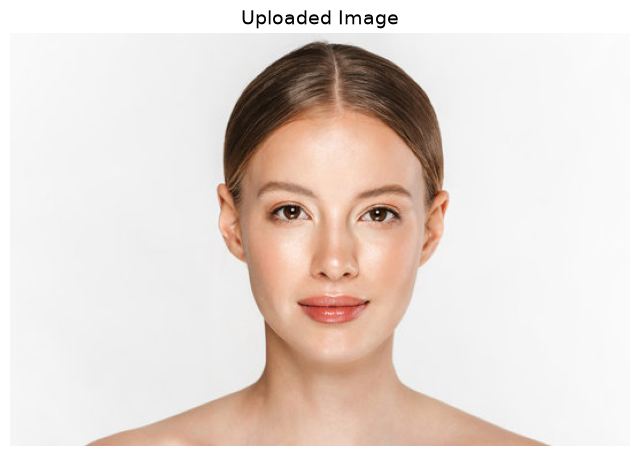

📁 Loaded: C:/Users/PratikJPatel/Downloads/360_F_276114144_xyAwCmx6IraojhvC2l9cNQEYAx6d28Nq.jpg  |  Size: 540×360


In [ ]:
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

file_path = filedialog.askopenfilename(
    title="Select a front-facing face image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")]
)
root.destroy()

if not file_path:
    raise ValueError("No file selected. Please run this cell again.")

pil_img = Image.open(file_path)
pil_img = ImageOps.exif_transpose(pil_img).convert('RGB')
image_rgb = np.array(pil_img)

plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('Uploaded Image', fontsize=14)
plt.show()
print(f"📁 Loaded: {file_path}  |  Size: {image_rgb.shape[1]}×{image_rgb.shape[0]}")


## 🔍 Step 2 — Detect Face Landmarks
Run MediaPipe to detect the 478 face mesh landmarks.


In [ ]:
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(image_rgb))
detection_result = detector.detect(mp_image)

if not detection_result.face_landmarks:
    raise RuntimeError("❌ No face detected in the image. Try a clearer, front-facing photo.")

landmarks = detection_result.face_landmarks[0]
h, w, _ = image_rgb.shape

def pt(idx):
    """Convert a landmark index to (x, y) pixel coordinates."""
    return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

print(f"✅ Detected {len(landmarks)} landmarks on a {w}×{h} image.")


✅ Detected 478 landmarks on a 540×360 image.


## 🗺️ Step 3 — Define Eye Landmark Indices

MediaPipe face mesh key eye landmarks:

| Region | Indices |
|--------|---------|
| Right eye upper contour | 246, 161, 160, 159, 158, 157, 173 |
| Right eye lower contour | 33, 7, 163, 144, 145, 153, 154, 155, 133 |
| Right iris centre | 468 |
| Left eye upper contour | 466, 388, 387, 386, 385, 384, 398 |
| Left eye lower contour | 263, 249, 390, 373, 374, 380, 381, 382, 362 |
| Left iris centre | 473 |
| Right eye corners | 33 (outer), 133 (inner) |
| Left eye corners | 362 (inner), 263 (outer) |


In [ ]:
# Right eye
RIGHT_EYE_UPPER = [246, 161, 160, 159, 158, 157, 173]
RIGHT_EYE_LOWER = [33, 7, 163, 144, 145, 153, 154, 155, 133]
RIGHT_IRIS_CENTER = 468
RIGHT_OUTER_CORNER = 33
RIGHT_INNER_CORNER = 133

# Left eye
LEFT_EYE_UPPER = [466, 388, 387, 386, 385, 384, 398]
LEFT_EYE_LOWER = [263, 249, 390, 373, 374, 380, 381, 382, 362]
LEFT_IRIS_CENTER = 473
LEFT_OUTER_CORNER = 263
LEFT_INNER_CORNER = 362

# Face width reference points (bizygomatic / cheekbone width)
FACE_WIDTH_LEFT = 234   # right cheekbone
FACE_WIDTH_RIGHT = 454  # left cheekbone

# Under-eye region (for darkness analysis)
RIGHT_UNDER_EYE = [33, 7, 163, 144, 145, 153, 154, 155, 133]
LEFT_UNDER_EYE = [263, 249, 390, 373, 374, 380, 381, 382, 362]

# IPD for mm conversion
IPD_MM = 63.0  # standard adult interpupillary distance

print("✅ Eye landmark indices defined.")


✅ Eye landmark indices defined.


## 👁️ Step 4 — Visualize Eye Landmarks


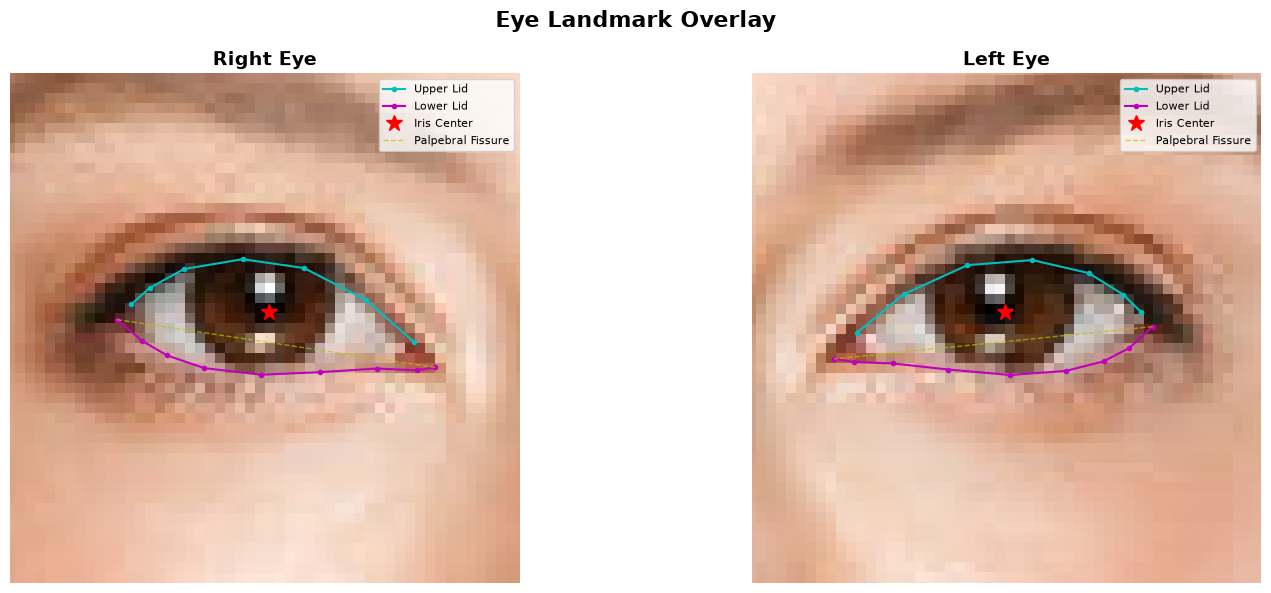

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, upper, lower, iris_idx, outer, inner) in zip(
    axes,
    [
        ("Right Eye", RIGHT_EYE_UPPER, RIGHT_EYE_LOWER, RIGHT_IRIS_CENTER, RIGHT_OUTER_CORNER, RIGHT_INNER_CORNER),
        ("Left Eye", LEFT_EYE_UPPER, LEFT_EYE_LOWER, LEFT_IRIS_CENTER, LEFT_OUTER_CORNER, LEFT_INNER_CORNER),
    ]
):
    # Gather all points to compute bounding box
    all_idxs = upper + lower + [iris_idx]
    all_pts = np.array([pt(i) for i in all_idxs])
    cx, cy = np.mean(all_pts, axis=0)
    span = max(np.ptp(all_pts[:, 0]), np.ptp(all_pts[:, 1])) * 1.6
    
    ax.imshow(image_rgb)
    
    # Upper eyelid
    upper_pts = np.array([pt(i) for i in upper])
    ax.plot(upper_pts[:, 0], upper_pts[:, 1], 'c-o', markersize=3, linewidth=1.5, label='Upper Lid')
    
    # Lower eyelid
    lower_pts = np.array([pt(i) for i in lower])
    ax.plot(lower_pts[:, 0], lower_pts[:, 1], 'm-o', markersize=3, linewidth=1.5, label='Lower Lid')
    
    # Iris center
    iris_pt = pt(iris_idx)
    ax.plot(iris_pt[0], iris_pt[1], 'r*', markersize=12, label='Iris Center')
    
    # Corners
    o_pt, i_pt = pt(outer), pt(inner)
    ax.plot([o_pt[0], i_pt[0]], [o_pt[1], i_pt[1]], 'y--', linewidth=1, alpha=0.7, label='Palpebral Fissure')
    
    ax.set_xlim(cx - span/2, cx + span/2)
    ax.set_ylim(cy + span/2, cy - span/2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.axis('off')

plt.suptitle('Eye Landmark Overlay', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 📐 Metric 1 — Eye Tilt (Canthal Tilt)

The **canthal tilt** measures the angle of the palpebral fissure (the line connecting the inner and outer eye corners) relative to the horizontal.

- **Positive** → outer corner is higher than inner corner (aesthetically desirable)
- **Neutral** → roughly level
- **Negative** → outer corner is lower (downturned)


In [ ]:
def compute_eye_tilt(outer_idx, inner_idx):
    """Compute tilt angle in degrees. Positive = outer corner higher."""
    outer = pt(outer_idx)
    inner = pt(inner_idx)
    dx = outer[0] - inner[0]
    dy = inner[1] - outer[1]  # inverted y: higher pixel = lower value
    angle_deg = np.degrees(np.arctan2(dy, abs(dx)))
    return angle_deg

right_tilt = compute_eye_tilt(RIGHT_OUTER_CORNER, RIGHT_INNER_CORNER)
left_tilt = compute_eye_tilt(LEFT_OUTER_CORNER, LEFT_INNER_CORNER)
avg_tilt = (right_tilt + left_tilt) / 2.0

if avg_tilt > 2.0:
    tilt_class = "Positive"
elif avg_tilt < -2.0:
    tilt_class = "Negative"
else:
    tilt_class = "Neutral"

print(f"┌────────────────────────────────────────┐")
print(f"│  EYE TILT (CANTHAL TILT)               │")
print(f"├────────────────────────────────────────┤")
print(f"│  Right Eye:  {right_tilt:+.2f}°                    │")
print(f"│  Left Eye:   {left_tilt:+.2f}°                    │")
print(f"│  Average:    {avg_tilt:+.2f}°                    │")
print(f"│  Class:      {tilt_class:<26s}│")
print(f"└────────────────────────────────────────┘")


┌────────────────────────────────────────┐
│  EYE TILT (CANTHAL TILT)               │
├────────────────────────────────────────┤
│  Right Eye:  +8.53°                    │
│  Left Eye:   +5.80°                    │
│  Average:    +7.17°                    │
│  Class:      Positive                  │
└────────────────────────────────────────┘


## 👀 Metric 2 — Eyelid Exposure

**Eyelid exposure** quantifies how much of the upper eyelid skin is visible between the crease and the lash line. It is computed as the ratio of the distance from iris center to the upper lid divided by the vertical eye aperture.

- **High** → more lid skin visible (open, alert appearance)
- **Moderate** → balanced amount
- **Low** → hooded eyes, less lid visible


In [ ]:
def compute_eyelid_exposure(upper_idxs, lower_idxs, iris_idx):
    """Compute eyelid exposure as ratio of upper-lid-to-iris vs total aperture."""
    iris = pt(iris_idx)
    
    # Find the upper lid point closest vertically above the iris
    upper_pts = np.array([pt(i) for i in upper_idxs])
    dists = np.abs(upper_pts[:, 0] - iris[0])
    closest_upper = upper_pts[np.argmin(dists)]
    
    # Find the lower lid point closest vertically below the iris
    lower_pts = np.array([pt(i) for i in lower_idxs])
    dists = np.abs(lower_pts[:, 0] - iris[0])
    closest_lower = lower_pts[np.argmin(dists)]
    
    upper_dist = iris[1] - closest_upper[1]  # positive = lid above iris
    total_aperture = closest_lower[1] - closest_upper[1]
    
    if total_aperture <= 0:
        return 0.5
    
    exposure = upper_dist / total_aperture
    return exposure

right_exposure = compute_eyelid_exposure(RIGHT_EYE_UPPER, RIGHT_EYE_LOWER, RIGHT_IRIS_CENTER)
left_exposure = compute_eyelid_exposure(LEFT_EYE_UPPER, LEFT_EYE_LOWER, LEFT_IRIS_CENTER)
avg_exposure = (right_exposure + left_exposure) / 2.0

if avg_exposure > 0.55:
    exposure_class = "High"
elif avg_exposure < 0.40:
    exposure_class = "Low"
else:
    exposure_class = "Moderate"

print(f"┌────────────────────────────────────────┐")
print(f"│  EYELID EXPOSURE                       │")
print(f"├────────────────────────────────────────┤")
print(f"│  Right Eye:  {right_exposure:.3f}                     │")
print(f"│  Left Eye:   {left_exposure:.3f}                     │")
print(f"│  Average:    {avg_exposure:.3f}                     │")
print(f"│  Class:      {exposure_class:<26s}│")
print(f"└────────────────────────────────────────┘")


┌────────────────────────────────────────┐
│  EYELID EXPOSURE                       │
├────────────────────────────────────────┤
│  Right Eye:  0.456                     │
│  Left Eye:   0.452                     │
│  Average:    0.454                     │
│  Class:      Moderate                  │
└────────────────────────────────────────┘


## 🎨 Metric 3 — Sclera Color

Sclera colour is assessed by sampling the pixel colour in the visible white area of the eye (between the iris and the inner/outer corners). The average brightness and colour cast determine the classification:

- **White** → clean, bright sclera
- **Off-White** → slight yellowish or reddish tint
- **Discoloured** → significant yellowing or redness


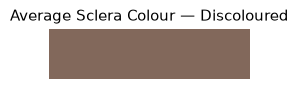

┌────────────────────────────────────────┐
│  SCLERA COLOR                          │
├────────────────────────────────────────┤
│  Right:  RGB(128, 103, 91)  → Discoloured │
│  Left:   RGB(133, 106, 92)  → Discoloured │
│  Overall:                   Discoloured │
└────────────────────────────────────────┘


In [ ]:
def sample_sclera_color(image, iris_idx, inner_idx, outer_idx):
    """Sample sclera colour from the medial and lateral white areas."""
    iris = pt(iris_idx).astype(int)
    inner = pt(inner_idx).astype(int)
    outer = pt(outer_idx).astype(int)
    
    samples = []
    
    # Sample from medial sclera (between iris and inner corner)
    mid_inner = ((iris + inner) // 2).astype(int)
    r = 5
    y1, y2 = max(0, mid_inner[1]-r), min(h, mid_inner[1]+r)
    x1, x2 = max(0, mid_inner[0]-r), min(w, mid_inner[0]+r)
    patch_inner = image[y1:y2, x1:x2]
    if patch_inner.size > 0:
        samples.append(np.mean(patch_inner, axis=(0, 1)))
    
    # Sample from lateral sclera (between iris and outer corner)
    mid_outer = ((iris + outer) // 2).astype(int)
    y1, y2 = max(0, mid_outer[1]-r), min(h, mid_outer[1]+r)
    x1, x2 = max(0, mid_outer[0]-r), min(w, mid_outer[0]+r)
    patch_outer = image[y1:y2, x1:x2]
    if patch_outer.size > 0:
        samples.append(np.mean(patch_outer, axis=(0, 1)))
    
    if not samples:
        return np.array([200, 200, 200]), "Unknown"
    
    avg_color = np.mean(samples, axis=0)  # RGB
    brightness = np.mean(avg_color)
    
    # Check for yellowish tint (R and G high, B low)
    rg_avg = (avg_color[0] + avg_color[1]) / 2
    yellow_tint = rg_avg - avg_color[2]
    
    # Check for reddish tint
    red_tint = avg_color[0] - (avg_color[1] + avg_color[2]) / 2
    
    if brightness > 180 and yellow_tint < 20 and red_tint < 15:
        classification = "White"
    elif brightness > 150:
        classification = "Off-White"
    else:
        classification = "Discoloured"
    
    return avg_color, classification

right_sclera_color, right_sclera_class = sample_sclera_color(
    image_rgb, RIGHT_IRIS_CENTER, RIGHT_INNER_CORNER, RIGHT_OUTER_CORNER)
left_sclera_color, left_sclera_class = sample_sclera_color(
    image_rgb, LEFT_IRIS_CENTER, LEFT_INNER_CORNER, LEFT_OUTER_CORNER)

# Use the most common classification
sclera_class = right_sclera_class if right_sclera_class == left_sclera_class else "Off-White"
avg_sclera = (right_sclera_color + left_sclera_color) / 2

# Display sclera color patch
fig, ax = plt.subplots(1, 1, figsize=(4, 1))
color_patch = np.ones((50, 200, 3), dtype=np.uint8)
color_patch[:, :] = avg_sclera.astype(np.uint8)
ax.imshow(color_patch)
ax.set_title(f"Average Sclera Colour — {sclera_class}", fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"┌────────────────────────────────────────┐")
print(f"│  SCLERA COLOR                          │")
print(f"├────────────────────────────────────────┤")
print(f"│  Right:  RGB({right_sclera_color[0]:.0f}, {right_sclera_color[1]:.0f}, {right_sclera_color[2]:.0f})  → {right_sclera_class:<12s}│")
print(f"│  Left:   RGB({left_sclera_color[0]:.0f}, {left_sclera_color[1]:.0f}, {left_sclera_color[2]:.0f})  → {left_sclera_class:<12s}│")
print(f"│  Overall:                   {sclera_class:<12s}│")
print(f"└────────────────────────────────────────┘")


## 🩺 Metric 4 — Under-Eye Health

Under-eye health is assessed by measuring the **relative darkness** of the skin directly below the lower eyelid compared to the cheek area. Dark circles are quantified as a brightness differential.


In [ ]:
def assess_under_eye_health(image, lower_idxs):
    """Assess under-eye darkness by comparing under-lid area to cheek."""
    lower_pts = np.array([pt(i) for i in lower_idxs], dtype=np.int32)
    
    # Create under-eye region: shift lower lid points downward
    under_eye_pts = lower_pts.copy()
    vertical_shift = int(np.ptp(lower_pts[:, 1]) * 0.8)
    under_eye_pts[:, 1] += vertical_shift
    
    # Create mask for under-eye
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [under_eye_pts], 255)
    
    # Convert to LAB for perceptual lightness
    lab_image = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    under_eye_L = lab_image[:, :, 0][mask > 0]
    
    if len(under_eye_L) == 0:
        return 0, "Unknown"
    
    avg_lightness = np.mean(under_eye_L)
    
    # Compare with cheek region (shift further down)
    cheek_pts = lower_pts.copy()
    cheek_pts[:, 1] += vertical_shift * 3
    mask_cheek = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask_cheek, [cheek_pts], 255)
    cheek_L = lab_image[:, :, 0][mask_cheek > 0]
    
    if len(cheek_L) == 0:
        darkness_diff = 0
    else:
        darkness_diff = np.mean(cheek_L) - avg_lightness
    
    if darkness_diff < 5:
        health_class = "Good"
    elif darkness_diff < 15:
        health_class = "Moderate"
    else:
        health_class = "Poor"
    
    return darkness_diff, health_class

right_darkness, right_health = assess_under_eye_health(image_rgb, RIGHT_EYE_LOWER)
left_darkness, left_health = assess_under_eye_health(image_rgb, LEFT_EYE_LOWER)
avg_darkness = (right_darkness + left_darkness) / 2.0

health_class = right_health if right_health == left_health else "Moderate"

print(f"┌────────────────────────────────────────┐")
print(f"│  UNDER-EYE HEALTH                      │")
print(f"├────────────────────────────────────────┤")
print(f"│  Right:  ΔL = {right_darkness:+.1f}  → {right_health:<16s}│")
print(f"│  Left:   ΔL = {left_darkness:+.1f}  → {left_health:<16s}│")
print(f"│  Avg:    ΔL = {avg_darkness:+.1f}  → {health_class:<16s}│")
print(f"└────────────────────────────────────────┘")


┌────────────────────────────────────────┐
│  UNDER-EYE HEALTH                      │
├────────────────────────────────────────┤
│  Right:  ΔL = +32.5  → Poor            │
│  Left:   ΔL = +24.7  → Poor            │
│  Avg:    ΔL = +28.6  → Poor            │
└────────────────────────────────────────┘


## 📏 Metric 5 — Lower Eyelid Curvature (Total Bending κ)

The **total bending** measures how curved the lower eyelid contour is. A higher value means a rounder, more curved lower lid. A lower value means a straighter, firmer contour.

The curvature κ is computed by fitting a spline to the lower lid points and integrating the absolute curvature along the curve.


┌────────────────────────────────────────┐
│  LOWER EYELID CURVATURE (κ)            │
├────────────────────────────────────────┤
│  Right Eye:  κ = 0.000                 │
│  Left Eye:   κ = 0.000                 │
│  Average:    κ = 0.000                 │
│  Typical Range:  0.69 — 0.96           │
└────────────────────────────────────────┘


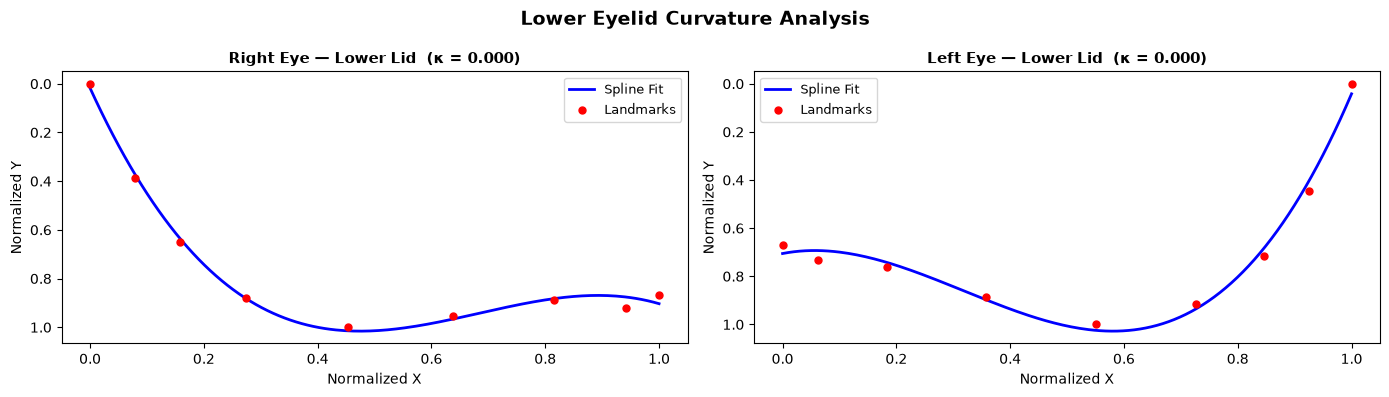

In [ ]:
def compute_lower_lid_curvature(lower_idxs):
    """Compute total bending (kappa) of the lower eyelid."""
    pts = np.array([pt(i) for i in lower_idxs])
    
    # Sort by x-coordinate
    sorted_idx = np.argsort(pts[:, 0])
    pts = pts[sorted_idx]
    
    x, y = pts[:, 0], pts[:, 1]
    
    # Normalize to [0, 1] range for stability
    x_range = x[-1] - x[0]
    y_range = np.ptp(y) if np.ptp(y) > 0 else 1
    x_norm = (x - x[0]) / x_range
    y_norm = (y - np.min(y)) / y_range
    
    # Fit spline
    try:
        spline = UnivariateSpline(x_norm, y_norm, s=0.01, k=3)
        
        # Compute curvature: κ = |y''| / (1 + y'²)^(3/2)
        t = np.linspace(0, 1, 200)
        dy = spline.derivative(n=1)(t)
        ddy = spline.derivative(n=2)(t)
        curvature = np.abs(ddy) / (1 + dy**2)**1.5
        
        # Total bending = integral of curvature
        total_bending = np.trapz(curvature, t)
    except Exception:
        total_bending = 0.0
    
    return total_bending

right_curvature = compute_lower_lid_curvature(RIGHT_EYE_LOWER)
left_curvature = compute_lower_lid_curvature(LEFT_EYE_LOWER)
avg_curvature = (right_curvature + left_curvature) / 2.0

print(f"┌────────────────────────────────────────┐")
print(f"│  LOWER EYELID CURVATURE (κ)            │")
print(f"├────────────────────────────────────────┤")
print(f"│  Right Eye:  κ = {right_curvature:.3f}                 │")
print(f"│  Left Eye:   κ = {left_curvature:.3f}                 │")
print(f"│  Average:    κ = {avg_curvature:.3f}                 │")
print(f"│  Typical Range:  0.69 — 0.96           │")
print(f"└────────────────────────────────────────┘")

# Visualize curvature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (title, lower_idxs, kappa) in zip(axes, [
    ("Right Eye — Lower Lid", RIGHT_EYE_LOWER, right_curvature),
    ("Left Eye — Lower Lid", LEFT_EYE_LOWER, left_curvature),
]):
    pts = np.array([pt(i) for i in lower_idxs])
    sorted_idx = np.argsort(pts[:, 0])
    pts = pts[sorted_idx]
    x, y = pts[:, 0], pts[:, 1]
    
    x_norm = (x - x[0]) / (x[-1] - x[0])
    y_range = np.ptp(y) if np.ptp(y) > 0 else 1
    y_norm = (y - np.min(y)) / y_range
    
    try:
        spline = UnivariateSpline(x_norm, y_norm, s=0.01, k=3)
        t = np.linspace(0, 1, 200)
        ax.plot(t, spline(t), 'b-', linewidth=2, label='Spline Fit')
    except:
        pass
    
    ax.plot(x_norm, y_norm, 'ro', markersize=5, label='Landmarks')
    ax.invert_yaxis()
    ax.set_title(f"{title}  (κ = {kappa:.3f})", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel("Normalized X")
    ax.set_ylabel("Normalized Y")

plt.suptitle("Lower Eyelid Curvature Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔷 Metric 6 — Eye Aspect Ratio (Almondness Ratio)

The **eye aspect ratio (EAR)** is the ratio of the vertical eye aperture to the horizontal width. A higher ratio indicates a more open, rounder eye; a lower ratio indicates a narrower, more almond-shaped eye.

- Typical range: **0.32 — 0.38**


In [ ]:
def compute_ear(upper_idxs, lower_idxs, outer_idx, inner_idx):
    """Compute Eye Aspect Ratio = vertical aperture / horizontal width."""
    outer = pt(outer_idx)
    inner = pt(inner_idx)
    eye_width = np.linalg.norm(outer - inner)
    
    # Vertical aperture: average of distances at 1/3 and 2/3 across
    upper_pts = np.array([pt(i) for i in upper_idxs])
    lower_pts = np.array([pt(i) for i in lower_idxs])
    
    # Find the midpoint vertically (near the iris)
    mid_x = (outer[0] + inner[0]) / 2
    
    # Closest upper point to mid_x
    u_dists = np.abs(upper_pts[:, 0] - mid_x)
    closest_upper = upper_pts[np.argmin(u_dists)]
    
    l_dists = np.abs(lower_pts[:, 0] - mid_x)
    closest_lower = lower_pts[np.argmin(l_dists)]
    
    eye_height = closest_lower[1] - closest_upper[1]
    
    if eye_width == 0:
        return 0
    
    return eye_height / eye_width

right_ear = compute_ear(RIGHT_EYE_UPPER, RIGHT_EYE_LOWER, RIGHT_OUTER_CORNER, RIGHT_INNER_CORNER)
left_ear = compute_ear(LEFT_EYE_UPPER, LEFT_EYE_LOWER, LEFT_OUTER_CORNER, LEFT_INNER_CORNER)
avg_ear = (right_ear + left_ear) / 2.0

print(f"┌────────────────────────────────────────┐")
print(f"│  EYE ASPECT RATIO (ALMONDNESS)         │")
print(f"├────────────────────────────────────────┤")
print(f"│  Right Eye:  {right_ear:.3f}                     │")
print(f"│  Left Eye:   {left_ear:.3f}                     │")
print(f"│  Average:    {avg_ear:.3f}                     │")
print(f"│  Typical Range:  0.32 — 0.38           │")
print(f"└────────────────────────────────────────┘")


┌────────────────────────────────────────┐
│  EYE ASPECT RATIO (ALMONDNESS)         │
├────────────────────────────────────────┤
│  Right Eye:  0.331                     │
│  Left Eye:   0.343                     │
│  Average:    0.337                     │
│  Typical Range:  0.32 — 0.38           │
└────────────────────────────────────────┘


## 📐 Metric 7 — Eye Spacing Ratio (IPD / Facial Width)

The **eye spacing ratio** measures how far apart the eyes are relative to the width of the face. It is calculated as the interpupillary distance (IPD) divided by the bizygomatic (cheekbone-to-cheekbone) width.

- Typical range: **0.22 — 0.24**


In [ ]:
p_lp = pt(LEFT_IRIS_CENTER)    # left iris
p_rp = pt(RIGHT_IRIS_CENTER)   # right iris
ipd_px = np.linalg.norm(p_lp - p_rp)

# Bizygomatic width
face_left = pt(FACE_WIDTH_LEFT)
face_right = pt(FACE_WIDTH_RIGHT)
face_width_px = np.linalg.norm(face_right - face_left)

spacing_ratio = ipd_px / face_width_px if face_width_px > 0 else 0

# Also convert IPD to mm
px_to_mm = IPD_MM / ipd_px
ipd_mm = ipd_px * px_to_mm  # should be ~63mm
face_width_mm = face_width_px * px_to_mm

print(f"┌────────────────────────────────────────┐")
print(f"│  EYE SPACING RATIO                     │")
print(f"├────────────────────────────────────────┤")
print(f"│  IPD:              {ipd_mm:.1f} mm               │")
print(f"│  Face Width:       {face_width_mm:.1f} mm             │")
print(f"│  Spacing Ratio:    {spacing_ratio:.3f}                │")
print(f"│  Typical Range:    0.22 — 0.24         │")
print(f"└────────────────────────────────────────┘")


┌────────────────────────────────────────┐
│  EYE SPACING RATIO                     │
├────────────────────────────────────────┤
│  IPD:              63.0 mm               │
│  Face Width:       134.4 mm             │
│  Spacing Ratio:    0.469                │
│  Typical Range:    0.22 — 0.24         │
└────────────────────────────────────────┘


## 🖼️ Step 5 — Isolated Eye Crops


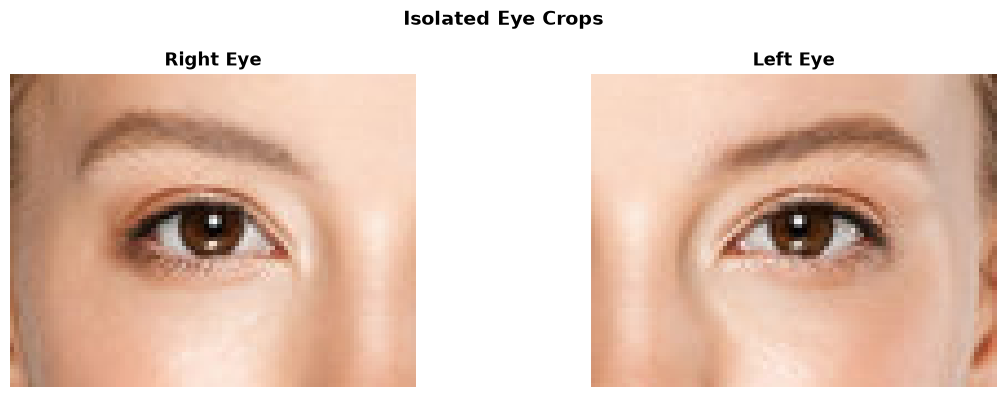

In [ ]:
def crop_eye(image, upper_idxs, lower_idxs, iris_idx, pad=30):
    """Crop the eye region from the image."""
    all_idxs = upper_idxs + lower_idxs + [iris_idx]
    pts = np.array([pt(i) for i in all_idxs], dtype=np.int32)
    x_min, y_min = np.min(pts, axis=0).astype(int)
    x_max, y_max = np.max(pts, axis=0).astype(int)
    x_min = max(0, x_min - pad)
    y_min = max(0, y_min - pad)
    x_max = min(w, x_max + pad)
    y_max = min(h, y_max + pad)
    return image[y_min:y_max, x_min:x_max]

right_eye_crop = crop_eye(image_rgb, RIGHT_EYE_UPPER, RIGHT_EYE_LOWER, RIGHT_IRIS_CENTER)
left_eye_crop = crop_eye(image_rgb, LEFT_EYE_UPPER, LEFT_EYE_LOWER, LEFT_IRIS_CENTER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(right_eye_crop)
axes[0].set_title("Right Eye", fontsize=13, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(left_eye_crop)
axes[1].set_title("Left Eye", fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.suptitle("Isolated Eye Crops", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 📊 Complete Eye Analysis Summary


In [ ]:
print("=" * 55)
print("     👁️  COMPREHENSIVE EYE ANALYSIS RESULTS  👁️")
print("=" * 55)
print()

metrics = [
    ("Eye Tilt", f"{avg_tilt:+.2f}°", tilt_class),
    ("Eyelid Exposure", f"{avg_exposure:.3f}", exposure_class),
    ("Sclera Color", f"RGB({avg_sclera[0]:.0f},{avg_sclera[1]:.0f},{avg_sclera[2]:.0f})", sclera_class),
    ("Under-Eye Health", f"ΔL = {avg_darkness:+.1f}", health_class),
    ("Lower Lid Curvature", f"κ = {avg_curvature:.3f}", "Range: 0.69–0.96"),
    ("Eye Aspect Ratio", f"{avg_ear:.3f}", "Range: 0.32–0.38"),
    ("Eye Spacing Ratio", f"{spacing_ratio:.3f}", "Range: 0.22–0.24"),
]

for name, value, note in metrics:
    print(f"  {name:<22s}  {value:<20s}  {note}")
    print()

print("=" * 55)
print("  Analysis complete. All metrics computed using")
print("  MediaPipe Face Mesh (478 landmarks).")
print("=" * 55)


     👁️  COMPREHENSIVE EYE ANALYSIS RESULTS  👁️

  Eye Tilt                +7.17°                Positive

  Eyelid Exposure         0.454                 Moderate

  Sclera Color            RGB(131,104,91)       Discoloured

  Under-Eye Health        ΔL = +28.6            Poor

  Lower Lid Curvature     κ = 0.000             Range: 0.69–0.96

  Eye Aspect Ratio        0.337                 Range: 0.32–0.38

  Eye Spacing Ratio       0.469                 Range: 0.22–0.24

  Analysis complete. All metrics computed using
  MediaPipe Face Mesh (478 landmarks).
